# NumPy and Linear Algebra - Tutorial

NumPy is the foundation of scientific computing in Python. This notebook covers essential NumPy operations following the module structure.

**Primary outcome:** You create and manipulate **ndarray** objects, filter with boolean masks, and use basic linear algebra helpers.

**Prerequisites:** [Introduction to Python](../1.2-intro-python/README.md); [Introduction to Statistics](../1.3-intro-statistics/README.md) helps for intuition. See the [NumPy README](./README.md).

> **Time needed:** About 90–150 minutes if you run all sections.

## Learning Objectives
- Understand data types and their measurement levels
- Learn why NumPy is essential for data science
- Create and manipulate NumPy arrays (ndarray)
- Perform array operations, indexing, and slicing
- Master boolean indexing for data filtering
- Apply array methods for reshaping and aggregation
- Use linear algebra operations for matrix computations

In [35]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


**Imports and environment check**

**What this code does:**
- Imports `numpy`, `matplotlib.pyplot`, and `time`, then prints `np.__version__` so you confirm the kernel sees the expected NumPy.


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import time

print(f"NumPy version: {np.__version__}")

NumPy version: 2.4.2


## 1. Data Foundations

Understanding data types is crucial for choosing appropriate analysis methods.

In [37]:
# Data Types Overview
# Understanding the 4 levels of measurement

print("="*50)
print("DATA TYPE LEVELS OF MEASUREMENT")
print("="*50)

print("\n1. NOMINAL (Categories without order)")
print("   Examples: Colors, Names, Gender")
print("   Operations: Count, Mode")
colors = np.array(['Red', 'Blue', 'Green', 'Red', 'Blue'])
unique, counts = np.unique(colors, return_counts=True)
print(f"   Colors: {colors}")
print(f"   Counts: {dict(zip(unique, counts))}")

print("\n2. ORDINAL (Categories with order)")
print("   Examples: Ratings (1-5 stars), Education level")
print("   Operations: Count, Mode, Median, Comparison")
ratings = np.array([3, 5, 4, 5, 2, 4, 5])
print(f"   Ratings: {ratings}")
print(f"   Median: {np.median(ratings)}")

print("\n3. INTERVAL (Equal spacing, no true zero)")
print("   Examples: Temperature (Celsius), Calendar years")
print("   Operations: +, -, Mean, Std")
temps = np.array([20, 25, 30, 15, 22])
print(f"   Temperatures: {temps}C")
print(f"   Mean: {np.mean(temps):.1f}C")

print("\n4. RATIO (True zero point)")
print("   Examples: Height, Weight, Age, Income")
print("   Operations: All math operations, ratios")
heights = np.array([165, 180, 155, 170, 175])
print(f"   Heights: {heights} cm")
print(f"   Tallest is {np.max(heights)/np.min(heights):.2f}x the shortest")

DATA TYPE LEVELS OF MEASUREMENT

1. NOMINAL (Categories without order)
   Examples: Colors, Names, Gender
   Operations: Count, Mode
   Colors: ['Red' 'Blue' 'Green' 'Red' 'Blue']
   Counts: {np.str_('Blue'): np.int64(2), np.str_('Green'): np.int64(1), np.str_('Red'): np.int64(2)}

2. ORDINAL (Categories with order)
   Examples: Ratings (1-5 stars), Education level
   Operations: Count, Mode, Median, Comparison
   Ratings: [3 5 4 5 2 4 5]
   Median: 4.0

3. INTERVAL (Equal spacing, no true zero)
   Examples: Temperature (Celsius), Calendar years
   Operations: +, -, Mean, Std
   Temperatures: [20 25 30 15 22]C
   Mean: 22.4C

4. RATIO (True zero point)
   Examples: Height, Weight, Age, Income
   Operations: All math operations, ratios
   Heights: [165 180 155 170 175] cm
   Tallest is 1.16x the shortest


## 2. Introduction to NumPy

NumPy provides fast, efficient array operations that are essential for data science.

In [ ]:
# Why NumPy? Speed Comparison
size = int(1e6) # 1_000_000 or 1000000 or 1e6

# Python list approach
python_list = list(range(size))
start = time.time()
python_result = [x * 2 for x in python_list]
python_time = time.time() - start

# NumPy approach
numpy_array = np.arange(size)
start = time.time()
numpy_result = numpy_array * 2
numpy_time = time.time() - start

print("Speed Comparison: Doubling 1 million numbers")
print(f"Python list: {python_time*1000:.2f} ms")
print(f"NumPy array: {numpy_time*1000:.2f} ms")
print(f"NumPy is {python_time/numpy_time:.0f}x faster!")

Speed Comparison: Doubling 1 million numbers
Python list: 30.23 ms
NumPy array: 0.32 ms
NumPy is 93x faster!


**Why NumPy is fast (concept + tiny demo)**

**What this code does:**
- Prints short bullet points, then builds `arr = np.array([1,2,3,4,5])` and prints `arr * 2` and `arr ** 2` to show elementwise arithmetic on the whole vector in one expression.


In [39]:
# Key NumPy Advantages
print("Why NumPy is fast:")
print("1. Vectorization - operates on entire arrays at once")
print("2. Contiguous memory - data stored efficiently")
print("3. C implementation - low-level optimizations")
print("4. Broadcasting - smart handling of different shapes")

# Simple example
arr = np.array([1, 2, 3, 4, 5])
print(f"\nArray: {arr}")
print(f"Doubled: {arr * 2}")
print(f"Squared: {arr ** 2}")

Why NumPy is fast:
1. Vectorization - operates on entire arrays at once
2. Contiguous memory - data stored efficiently
3. C implementation - low-level optimizations
4. Broadcasting - smart handling of different shapes

Array: [1 2 3 4 5]
Doubled: [ 2  4  6  8 10]
Squared: [ 1  4  9 16 25]


## 3. NumPy ndarray

The ndarray (N-dimensional array) is NumPy's core data structure.

In [ ]:
data = np.array([1, 2, 3, 4, 5])
print(data * 3) # map across all elements in the list, and apply an operation on each element
print(data + data) # map across all elements in the list, and apply an operation on each element

data_2 = [1, 2, 3, 4, 5]
print(data_2 * 3) # repeat operation
print(data_2 + data_2) # append operation


[ 3  6  9 12 15]
[ 2  4  6  8 10]
[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
[1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


**Create arrays from lists; reshape dtypes**

**What this code does:**
- Builds `arr1d` from a mixed list (promotes to float) and `arr2d` from nested lists (strings).
- Converts with `arr1d.astype("i1")` to 1-byte integers and prints the array and `dtype`.


In [92]:
# Creating arrays from Python lists
arr1d = np.array([1, 2.2, 3, 4.0, 5])
arr2d = np.array([["1", "2", "3"], ["4", "5", "6"]])

# print("1D Array:")
# print(arr1d)
# print(f"Shape: {arr1d.shape}, ndim: {arr1d.ndim}")
# print(f"Data type: {arr1d.dtype}")

# print("\n2D Array:")
# print(arr2d)
# print(f"Shape: {arr2d.shape}, ndim: {arr2d.ndim}")
# print(f"Data type: {arr2d.dtype}")

arr_new = arr1d.astype("i1")
print(arr_new)
print(arr_new.dtype)



# print(arr2d+arr2d)
# arr2d = arr2d.astype(int)
# print(arr2d)
# print(arr2d+arr2d)

# test_array = ["1", "2", "3", "4", "5"]
# # map across all elements in the list, and apply an operation on each element without using numpy
# # list(map(int, test_array))
# print(list(map(int, test_array)))


[1 2 3 4 5]
int8


**Factory helpers: zeros, ones, identity, ranges**

**What this code does:**
- Prints `np.zeros((3,4))`, `np.ones((2,3))`, `np.eye(3)`, `np.arange(0,10,2)`, and `np.linspace(0,1,5)`—each call allocates a new array with a known pattern.


In [41]:
# Built-in array creation functions
print("zeros(3, 4):")
print(np.zeros((3, 4)))

print("\nones(2, 3):")
print(np.ones((2, 3)))

print("\neye(3) - Identity matrix:")
print(np.eye(3))

print("\narange(0, 10, 2):")
print(np.arange(0, 10, 2))

print("\nlinspace(0, 1, 5):")
print(np.linspace(0, 1, 5))

zeros(3, 4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

ones(2, 3):
[[1. 1. 1.]
 [1. 1. 1.]]

eye(3) - Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

arange(0, 10, 2):
[0 2 4 6 8]

linspace(0, 1, 5):
[0.   0.25 0.5  0.75 1.  ]


**Random arrays**

**What this code does:**
- Sets `np.random.seed(42)` for reproducibility, then prints `rand` (uniform [0,1)), `randn` (standard normal), and `randint(1,11, size=(2,3))` (integer samples).


In [42]:
# Random arrays
np.random.seed(42)

print("Random uniform [0, 1):")
print(np.random.rand(2, 3))

print("\nRandom normal (mean=0, std=1):")
print(np.random.randn(2, 3))

print("\nRandom integers [1, 10]:")
print(np.random.randint(1, 11, size=(2, 3)))

Random uniform [0, 1):
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]

Random normal (mean=0, std=1):
[[ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]]

Random integers [1, 10]:
[[10  6  9]
 [ 1 10  3]]


**`dtype` and `astype`**

**What this code does:**
- Prints int and float arrays and their `dtype`s, converts integers to float with `astype`, then truncates floats to int32 with `astype(np.int32)` and prints before/after.


In [43]:
# Data Types (dtype)
int_arr = np.array([1, 2, 3, 4, 5])
float_arr = np.array([1.5, 2.5, 3.5])

print(f"Integer array: {int_arr}")
print(f"dtype: {int_arr.dtype}")

print(f"\nFloat array: {float_arr}")
print(f"dtype: {float_arr.dtype}")

# Type conversion with astype()
converted = int_arr.astype(np.float64)
print(f"\nConverted to float: {converted}")
print(f"New dtype: {converted.dtype}")

# Float to int (truncates decimals)
float_nums = np.array([3.7, -1.2, 2.6, 0.5])
int_nums = float_nums.astype(np.int32)
print(f"\nFloat to int (truncates): {float_nums} -> {int_nums}")

Integer array: [1 2 3 4 5]
dtype: int64

Float array: [1.5 2.5 3.5]
dtype: float64

Converted to float: [1. 2. 3. 4. 5.]
New dtype: float64

Float to int (truncates): [ 3.7 -1.2  2.6  0.5] -> [ 3 -1  2  0]


## 4. ndarray Basics

Arithmetic operations, broadcasting, and indexing.

**Elementwise arithmetic on a 2D array**

**What this code does:**
- Creates `arr` as a 2×3 float matrix and prints it.
- Prints `arr + 10` and `arr * 2` (scalar broadcasts to every entry).
- Prints `arr ** 2` elementwise, then `np.sqrt(arr)` (ufunc applied to each element).


In [44]:
# Arithmetic operations (vectorized)
arr = np.array([[1.0, 2.0, 3.0],
                [4.0, 5.0, 6.0]])

print("Original array:")
print(arr)

print("\nAddition (arr + 10):")
print(arr + 10)

print("\nMultiplication (arr * 2):")
print(arr * 2)

print("\nSquare (arr ** 2):")
print(arr ** 2)

print("\nSquare root:")
print(np.sqrt(arr))

Original array:
[[1. 2. 3.]
 [4. 5. 6.]]

Addition (arr + 10):
[[11. 12. 13.]
 [14. 15. 16.]]

Multiplication (arr * 2):
[[ 2.  4.  6.]
 [ 8. 10. 12.]]

Square (arr ** 2):
[[ 1.  4.  9.]
 [16. 25. 36.]]

Square root:
[[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]


**Broadcasting**

**What this code does:**
- Adds `10` to a 1D array (scalar broadcasts across the vector), then multiplies by `2`.
- Adds a 1D vector to a 2D matrix so the vector broadcasts across rows (see printed shapes in output).


In [98]:
# Broadcasting - operations with different shapes
print("Scalar Broadcasting:")
arr = np.array([1, 2, 3, 4])
print(f"arr = {arr}")
print(f"arr + 10 = {arr + 10}")
print(f"arr * 2 = {arr * 2}")

print("\nArray Broadcasting:")
matrix = np.arange(1, 13).reshape(4, 3)
row = np.array([10, 20, 30])

print("Matrix:")
print(matrix)
print(f"\nRow vector: {row}")
print("\nMatrix + Row:")
print(matrix * row)

Scalar Broadcasting:
arr = [1 2 3 4]
arr + 10 = [11 12 13 14]
arr * 2 = [2 4 6 8]

Array Broadcasting:
Matrix:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

Row vector: [10 20 30]

Matrix + Row:
[[ 10  40  90]
 [ 40 100 180]
 [ 70 160 270]
 [100 220 360]]


**Elementwise comparisons**

**What this code does:**
- Compares two same-shape 2D arrays with `>`, `==`, and chained comparisons, producing boolean arrays of the same shape.


In [100]:
# Comparing arrays
arr1 = np.array([[1, 2, 3], [4, 5, 6]])
arr2 = np.array([[0, 4, 1], [7, 2, 12]])

print("Array 1:")
print(arr1)
print("\nArray 2:")
print(arr2)
print("\narr2 > arr1:")
print(arr2 > arr1)

Array 1:
[[1 2 3]
 [4 5 6]]

Array 2:
[[ 0  4  1]
 [ 7  2 12]]

arr2 > arr1:
[[False  True False]
 [ True False  True]]


**1D indexing and slices**

**What this code does:**
- Uses integer indices, slices (`2:7`), negative indices, and two-element slices (`1:8:2`) on `np.arange(10)`.


In [47]:
# Indexing and Slicing - 1D arrays
arr = np.arange(10)
print(f"Array: {arr}")

print(f"\nFirst element: {arr[0]}")
print(f"Last element: {arr[-1]}")
print(f"Elements 2-5: {arr[2:6]}")
print(f"Every 2nd element: {arr[::2]}")
print(f"Reversed: {arr[::-1]}")

Array: [0 1 2 3 4 5 6 7 8 9]

First element: 0
Last element: 9
Elements 2-5: [2 3 4 5]
Every 2nd element: [0 2 4 6 8]
Reversed: [9 8 7 6 5 4 3 2 1 0]


**2D indexing and slices**

**What this code does:**
- On a 3×4 matrix, selects rows, columns, single elements, row slices, column slices, and sub-blocks (`[0:2, 1:3]`).


In [48]:
# Indexing and Slicing - 2D arrays
matrix = np.arange(1, 13).reshape(3, 4)
print("Matrix:")
print(matrix)

print(f"\nElement at (1, 2): {matrix[1, 2]}")
print(f"First row: {matrix[0]}")
print(f"First column: {matrix[:, 0]}")
print(f"Submatrix (rows 0-1, cols 1-2):\n{matrix[:2, 1:3]}")

Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Element at (1, 2): 7
First row: [1 2 3 4]
First column: [1 5 9]
Submatrix (rows 0-1, cols 1-2):
[[2 3]
 [6 7]]


## 5. Boolean Indexing

Filter data using boolean conditions.

In [49]:
# Basic boolean indexing
arr = np.array([1, 5, 3, 8, 2, 9, 4, 7])

print(f"Array: {arr}")
print(f"\nGreater than 5: {arr[arr > 5]}")
print(f"Even numbers: {arr[arr % 2 == 0]}")
print(f"Between 3 and 7: {arr[(arr >= 3) & (arr <= 7)]}")

Array: [1 5 3 8 2 9 4 7]

Greater than 5: [8 9 7]
Even numbers: [8 2 4]
Between 3 and 7: [5 3 4 7]


**Combine boolean conditions**

**What this code does:**
- Builds masks with `>`, combines with `&` and `|` (with parentheses), and negates with `~`—each step prints a boolean array.


In [50]:
# Combining conditions with & (AND), | (OR), ~ (NOT)
arr = np.array([1, 5, 3, 8, 2, 9, 4, 7])
print(f"Array: {arr}")

print(f"\nLess than 3 OR greater than 7: {arr[(arr < 3) | (arr > 7)]}")
print(f"NOT greater than 5: {arr[~(arr > 5)]}")

Array: [1 5 3 8 2 9 4 7]

Less than 3 OR greater than 7: [1 8 2 9]
NOT greater than 5: [1 5 3 2 4]


**Masking with real labels**

**What this code does:**
- Uses parallel arrays `names` and `scores`, filters scores with `scores >= 5`, then uses that mask to subset `names` to students who passed.


In [101]:
# Practical example: Student scores
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
scores = np.array([
    [85, 90],   # Joe's scores
    [75, 80],   # Bob's scores [math, science]
    [95, 100],  # Will's scores
    [100, 77],  # Bob's scores
    [85, 92],   # Will's scores
    [95, 80],   # Joe's scores
    [72, 80]    # Joe's scores
])

# Get Bob's scores using boolean mask
bob_mask = names == "Bob"
print(f"Bob mask: {bob_mask}")
print(f"\nBob's scores:\n{scores[bob_mask]}")
print(f"Bob's average: {scores[bob_mask].mean():.1f}")

Bob mask: [ True False False  True False False False]

Bob's scores:
[[ 85  90]
 [100  77]]
Bob's average: 88.0


**Assign through a mask**

**What this code does:**
- Copies `arr`, then assigns `5` everywhere `arr > 2` is True, and prints before/after.


In [52]:
# Modifying values with boolean masks
arr = np.array([1, 5, 3, 8, 2, 9, 4, 7])
print(f"Original: {arr}")

arr_copy = arr.copy()
arr_copy[arr_copy < 5] = 0  # Set all values less than 5 to 0
print(f"After setting values < 5 to 0: {arr_copy}")

Original: [1 5 3 8 2 9 4 7]
After setting values < 5 to 0: [0 5 0 8 0 9 0 7]


## 6. ndarray Methods

Reshaping, universal functions, statistics, and conditional operations.

In [53]:
# Reshaping arrays
arr = np.arange(12)
print(f"Original: {arr}")
print(f"Shape: {arr.shape}")

reshaped = arr.reshape(3, 4)
print(f"\nReshaped (3x4):\n{reshaped}")

print(f"\nFlattened: {reshaped.flatten()}")
print(f"\nTransposed:\n{reshaped.T}")

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)

Reshaped (3x4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Transposed:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


**Stack arrays**

**What this code does:**
- Vertically and horizontally stacks 1D arrays `a` and `b` with `vstack` and `hstack`.


In [54]:
# Stacking arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(f"Vertical stack:\n{np.vstack([a, b])}")
print(f"\nHorizontal stack: {np.hstack([a, b])}")
print(f"\nColumn stack:\n{np.column_stack([a, b])}")

Vertical stack:
[[1 2 3]
 [4 5 6]]

Horizontal stack: [1 2 3 4 5 6]

Column stack:
[[1 4]
 [2 5]
 [3 6]]


**Universal functions and a quick plot**

**What this code does:**
- Creates `x = np.linspace(0, 2π, 100)` and plots `sin(x)` and `cos(x)` in two subplots with matplotlib.


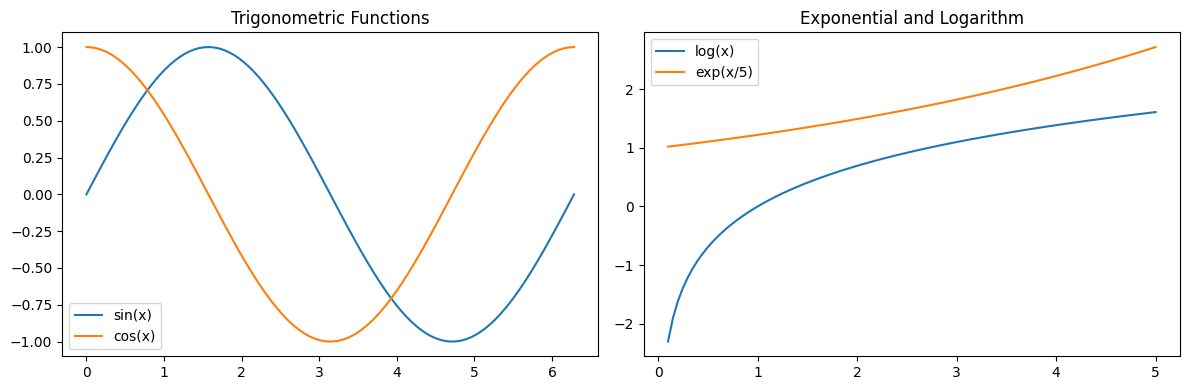

In [55]:
# Universal functions (ufuncs)
x = np.linspace(0, 2*np.pi, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, np.sin(x), label='sin(x)')
axes[0].plot(x, np.cos(x), label='cos(x)')
axes[0].legend()
axes[0].set_title('Trigonometric Functions')

y = np.linspace(0.1, 5, 100)
axes[1].plot(y, np.log(y), label='log(x)')
axes[1].plot(y, np.exp(y/5), label='exp(x/5)')
axes[1].legend()
axes[1].set_title('Exponential and Logarithm')

plt.tight_layout()
plt.show()

**`np.where` conditional selection**

**What this code does:**
- Calls `np.where(arr > 5, arr, 0)` so elements ≤5 become 0 and elements >5 stay unchanged; prints the result.


In [56]:
# np.where() - conditional selection
arr = np.array([1, 5, 3, 8, 2, 9, 4, 7])
print(f"Array: {arr}")

# Replace values: if > 5, keep value; else replace with 0
result = np.where(arr > 5, arr, 0)
print(f"np.where(arr > 5, arr, 0): {result}")

# Replace with labels
result2 = np.where(arr > 5, "high", "low")
print(f"np.where(arr > 5, 'high', 'low'): {result2}")

Array: [1 5 3 8 2 9 4 7]
np.where(arr > 5, arr, 0): [0 0 0 8 0 9 0 7]
np.where(arr > 5, 'high', 'low'): ['low' 'low' 'low' 'high' 'low' 'high' 'low' 'high']


**Aggregate over the whole array**

**What this code does:**
- On a `np.random.randint` matrix, prints `sum`, `mean`, `std`, `min`, `max` across all elements (global reductions).


In [57]:
# Aggregation functions
np.random.seed(42)
data = np.random.randint(1, 100, size=(4, 5))
print("Data:")
print(data)

print(f"\nSum: {np.sum(data)}")
print(f"Mean: {np.mean(data):.2f}")
print(f"Std: {np.std(data):.2f}")
print(f"Min: {np.min(data)}, Max: {np.max(data)}")

Data:
[[52 93 15 72 61]
 [21 83 87 75 75]
 [88 24  3 22 53]
 [ 2 88 30 38  2]]

Sum: 984
Mean: 49.20
Std: 31.57
Min: 2, Max: 93


**Aggregate along an axis**

**What this code does:**
- Prints `np.sum(data, axis=1)` (row sums) and `np.sum(data, axis=0)` (column sums) so you see how `axis` picks which dimension collapses.


In [58]:
# Aggregation along axes
print("Data:")
print(data)
print(f"\nSum along rows (axis=1): {np.sum(data, axis=1)}")
print(f"Mean along columns (axis=0): {np.mean(data, axis=0)}")
print(f"Max along rows: {np.max(data, axis=1)}")

Data:
[[52 93 15 72 61]
 [21 83 87 75 75]
 [88 24  3 22 53]
 [ 2 88 30 38  2]]

Sum along rows (axis=1): [293 341 190 160]
Mean along columns (axis=0): [40.75 72.   33.75 51.75 47.75]
Max along rows: [93 87 88 88]


**`any` and `all` on booleans**

**What this code does:**
- Evaluates `np.any` / `np.all` on a boolean vector and on a boolean matrix with `axis=0` and `axis=1`.


In [59]:
# Boolean aggregation: any() and all()
bools = np.array([True, False, True, True])
print(f"Boolean array: {bools}")
print(f"Any True? {bools.any()}")
print(f"All True? {bools.all()}")

# Practical example
arr = np.array([1, 5, 3, 8, 2, 9, 4, 7])
print(f"\nArray: {arr}")
print(f"Any value > 8? {(arr > 8).any()}")
print(f"All values > 0? {(arr > 0).all()}")

Boolean array: [ True False  True  True]
Any True? True
All True? False

Array: [1 5 3 8 2 9 4 7]
Any value > 8? True
All values > 0? True


**Sort and argsort**

**What this code does:**
- Prints `np.sort(arr)` (sorted copy) and `np.argsort(arr)` (indices that would sort the array).


In [60]:
# Sorting
arr = np.array([3, 1, 4, 1, 5, 9, 2, 6])
print(f"Original: {arr}")
print(f"Sorted: {np.sort(arr)}")
print(f"Indices that would sort: {np.argsort(arr)}")

Original: [3 1 4 1 5 9 2 6]
Sorted: [1 1 2 3 4 5 6 9]
Indices that would sort: [1 3 6 0 2 4 7 5]


## 7. Linear Algebra

Set operations and matrix computations.

In [61]:
# Set operations - finding unique values
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])
print(f"Names: {names}")

# Get unique values and counts
unique_names, counts = np.unique(names, return_counts=True)
print(f"Unique names: {unique_names}")
print(f"Counts: {counts}")

# Check membership with in1d
inventory = np.array([1, 2, 3, 4, 5])
to_check = np.array([2, 3, 6])
print(f"\nInventory: {inventory}")
print(f"Items to check: {to_check}")
print(f"In inventory? {np.isin(to_check, inventory)}")

Names: ['Bob' 'Will' 'Joe' 'Bob' 'Will' 'Joe' 'Joe']
Unique names: ['Bob' 'Joe' 'Will']
Counts: [2 3 2]

Inventory: [1 2 3 4 5]
Items to check: [2 3 6]
In inventory? [ True  True False]


**Matrix multiplication vs elementwise product**

**What this code does:**
- Prints `A` and `B`, then `A @ B` (matrix multiply) and `A * B` (same-shape elementwise product)—same symbols as in math vs NumPy’s `*` rule.


In [62]:
# Matrix multiplication
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A:")
print(A)
print("\nB:")
print(B)

print("\nMatrix multiplication (A @ B):")
print(A @ B)

print("\nElement-wise multiplication (A * B):")
print(A * B)

A:
[[1 2]
 [3 4]]

B:
[[5 6]
 [7 8]]

Matrix multiplication (A @ B):
[[19 22]
 [43 50]]

Element-wise multiplication (A * B):
[[ 5 12]
 [21 32]]


**Determinant and inverse**

**What this code does:**
- Prints `det(A)`, `inv(A)`, and `A @ inv(A)` rounded to verify the identity matrix.


In [63]:
# Linear algebra operations
A = np.array([[4, 2], [1, 3]])
print("Matrix A:")
print(A)

print(f"\nDeterminant: {np.linalg.det(A):.2f}")

print("\nInverse:")
print(np.linalg.inv(A))

# Verify A @ A^-1 = I
print("\nA @ A^-1 (should be identity):")
print(np.round(A @ np.linalg.inv(A)))

Matrix A:
[[4 2]
 [1 3]]

Determinant: 10.00

Inverse:
[[ 0.3 -0.2]
 [-0.1  0.4]]

A @ A^-1 (should be identity):
[[ 1.  0.]
 [-0.  1.]]


**Solve \(Ax = b\)**

**What this code does:**
- Defines `A` and `b` for a 2×2 system, calls `np.linalg.solve(A, b)` to get `x`, then plugs `x` back into the two equations to print verification lines.


In [64]:
# Solving linear equations: Ax = b
# 2x + y = 8
# x + 3y = 13

A = np.array([[2, 1], [1, 3]])
b = np.array([8, 13])

x = np.linalg.solve(A, b)
print(f"Solution: x = {x[0]:.1f}, y = {x[1]:.1f}")

# Verify
print(f"\nVerification:")
print(f"2({x[0]:.1f}) + ({x[1]:.1f}) = {2*x[0] + x[1]:.1f}")
print(f"({x[0]:.1f}) + 3({x[1]:.1f}) = {x[0] + 3*x[1]:.1f}")

Solution: x = 2.2, y = 3.6

Verification:
2(2.2) + (3.6) = 8.0
(2.2) + 3(3.6) = 13.0


**Rank, trace, eigenvalues**

**What this code does:**
- Prints `matrix_rank`, `trace`, then `eig` which returns eigenvalues and eigenvector columns for `A`.


In [65]:
# Advanced matrix properties
A = np.array([[4, -2], [1, 1]])
print("Matrix A:")
print(A)

# Matrix rank
print(f"\nRank: {np.linalg.matrix_rank(A)}")

# Trace (sum of diagonal elements)
print(f"Trace: {np.trace(A)}")

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

Matrix A:
[[ 4 -2]
 [ 1  1]]

Rank: 2
Trace: 5

Eigenvalues: [3. 2.]
Eigenvectors:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]


## 8. Practice Exercises

### Exercise 1: Create a 5x5 matrix with 1s on the border and 0s inside

In [66]:
# Your code here

# --- Solution (uncomment to run) ---
# border_matrix = np.ones((5, 5))
# border_matrix[1:-1, 1:-1] = 0
# print(border_matrix)
# Expected output:
# [[1. 1. 1. 1. 1.]
#  [1. 0. 0. 0. 1.]
#  [1. 0. 0. 0. 1.]
#  [1. 0. 0. 0. 1.]
#  [1. 1. 1. 1. 1.]]

### Exercise 2: Normalize an array to range [0, 1]

In [67]:
arr = np.array([10, 20, 30, 40, 50])
# Normalize so min=0 and max=1
# Your code here

# --- Solution (uncomment to run) ---
# normalized = (arr - arr.min()) / (arr.max() - arr.min())
# print(f"Original: {arr}")
# print(f"Normalized: {normalized}")
# Expected output: [0.   0.25 0.5  0.75 1.  ]

### Exercise 3: Replace negative values with zero using np.where()

In [68]:
arr = np.array([5, -3, 2, -8, 0, 4, -1])
# Replace all negative values with 0
# Your code here

# --- Solution (uncomment to run) ---
# result = np.where(arr < 0, 0, arr)
# print(f"Original: {arr}")
# print(f"Result: {result}")
# Expected output: [5 0 2 0 0 4 0]

### Exercise 4: Find unique values and their counts in an array

In [69]:
grades = np.array(['A', 'B', 'A', 'C', 'B', 'A', 'B', 'C', 'A', 'D'])
# Find unique grades and how many of each
# Your code here

# --- Solution (uncomment to run) ---
# unique_grades, counts = np.unique(grades, return_counts=True)
# print(f"Grades: {grades}")
# print(f"Unique grades: {unique_grades}")
# print(f"Counts: {counts}")
# for grade, count in zip(unique_grades, counts):
#     print(f"  {grade}: {count}")
# Expected output:
# Unique grades: ['A' 'B' 'C' 'D']
# Counts: [4 3 2 1]

---

<details>
<summary>Click to see solutions</summary>

```python
# Exercise 1 Solution - Border matrix
border_matrix = np.ones((5, 5))
border_matrix[1:-1, 1:-1] = 0
print(border_matrix)

# Exercise 2 Solution - Normalization
arr = np.array([10, 20, 30, 40, 50])
normalized = (arr - arr.min()) / (arr.max() - arr.min())
print(normalized)

# Exercise 3 Solution - Replace negatives with np.where()
arr = np.array([5, -3, 2, -8, 0, 4, -1])
result = np.where(arr < 0, 0, arr)
print(result)

# Exercise 4 Solution - Unique values and counts
grades = np.array(['A', 'B', 'A', 'C', 'B', 'A', 'B', 'C', 'A', 'D'])
unique_grades, counts = np.unique(grades, return_counts=True)
print(f"Unique grades: {unique_grades}")
print(f"Counts: {counts}")
```
</details>

## Summary

Following the module structure, you've learned:

1. **Data Foundations** - Understanding data types (nominal, ordinal, interval, ratio)
2. **Introduction to NumPy** - Why NumPy is fast (vectorization, contiguous memory)
3. **NumPy ndarray** - Creating arrays, data types (dtype), and type conversion
4. **ndarray Basics** - Arithmetic operations, broadcasting, indexing, and slicing
5. **Boolean Indexing** - Filtering with conditions, combining masks (&, |, ~)
6. **ndarray Methods** - Reshaping, transpose, ufuncs, np.where(), aggregation, sorting
7. **Linear Algebra** - Set operations (unique, in1d), matrix multiplication, linalg operations

## Next steps in this course

- Continue with [Data analysis with pandas](../1.5-data-analysis-pandas/README.md) and the [pandas tutorial notebook](../1.5-data-analysis-pandas/tutorial.ipynb).